### Model Comparison Summary: Logistic Regression vs XGBoost

#### OBJECTIVE:
Compare baseline and advanced models to justify XGBoost deployment

#### BUSINESS QUESTION:
Is the additional complexity of XGBoost worth the performance gain?

#### ANSWER:
Yes - XGBoost catches the same fraud with 64% fewer false alarms,
reducing manual review costs while maintaining fraud detection rate.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

MODEL COMPARISON SUMMARY


In [3]:

# ==============================================================================
# LOAD MODELS AND DATA
# ==============================================================================

print("\nLoading models and data...")
print("-" * 80)

# Load both models
PROJECT_ROOT = Path().resolve().parents[1]
lr_model = joblib.load(PROJECT_ROOT/'models'/'fraud'/'baseline_logistic_regression.pkl')
xgb_model = joblib.load(PROJECT_ROOT/'models'/'fraud'/'xgboost_model.pkl')
scaler = joblib.load(PROJECT_ROOT/'models'/'fraud'/'feature_scaler.pkl')
feature_list = joblib.load(PROJECT_ROOT/'models'/'fraud'/'feature_list.pkl')

# Load data and recreate test set
inpatient = pd.read_csv(PROJECT_ROOT/'data'/'processed'/'inpatient_labeled.csv')
X = inpatient[feature_list].fillna(inpatient[feature_list].median())
y = inpatient['is_fraud_80']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Test set: {len(X_test):,} claims")
print(f"Fraud cases: {y_test.sum()} ({y_test.mean()*100:.2f}%)")



Loading models and data...
--------------------------------------------------------------------------------
Test set: 13,355 claims
Fraud cases: 46 (0.34%)


In [4]:
# ==============================================================================
# GET PREDICTIONS FROM BOTH MODELS
# ==============================================================================

print("\nGenerating predictions...")
print("-" * 80)

# Logistic Regression (needs scaled data)
X_test_scaled = scaler.transform(X_test)
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# XGBoost (uses unscaled data)
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("Predictions generated for both models")



Generating predictions...
--------------------------------------------------------------------------------
Predictions generated for both models


In [5]:

# ==============================================================================
# CALCULATE METRICS
# ==============================================================================

print("\nCalculating performance metrics...")
print("-" * 80)

def calculate_metrics(y_true, y_pred, y_pred_proba):
    """Calculate comprehensive metrics"""
    from sklearn.metrics import confusion_matrix
    
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    return {
        'ROC-AUC': roc_auc_score(y_true, y_pred_proba),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'True Positives': int(tp),
        'False Positives': int(fp),
        'False Negatives': int(fn),
        'True Negatives': int(tn),
        'Accuracy': (tp + tn) / (tp + tn + fp + fn)
    }

lr_metrics = calculate_metrics(y_test, y_pred_lr, y_pred_proba_lr)
xgb_metrics = calculate_metrics(y_test, y_pred_xgb, y_pred_proba_xgb)

# Create comparison dataframe
comparison_df = pd.DataFrame({
    'Metric': list(lr_metrics.keys()),
    'Logistic Regression': list(lr_metrics.values()),
    'XGBoost': list(xgb_metrics.values())
})

# Calculate improvements
comparison_df['Absolute Difference'] = comparison_df['XGBoost'] - comparison_df['Logistic Regression']
comparison_df['Percent Change'] = ((comparison_df['XGBoost'] - comparison_df['Logistic Regression']) / 
                                    comparison_df['Logistic Regression'] * 100).round(1)

print("\nPerformance Comparison:")
print("="*80)
print(comparison_df.to_string(index=False))



Calculating performance metrics...
--------------------------------------------------------------------------------

Performance Comparison:
         Metric  Logistic Regression      XGBoost  Absolute Difference  Percent Change
        ROC-AUC             0.998117     0.999080             0.000964             0.1
      Precision             0.333333     0.578947             0.245614            73.7
         Recall             0.956522     0.956522             0.000000             0.0
       F1-Score             0.494382     0.721311             0.226929            45.9
 True Positives            44.000000    44.000000             0.000000             0.0
False Positives            88.000000    32.000000           -56.000000           -63.6
False Negatives             2.000000     2.000000             0.000000             0.0
 True Negatives         13221.000000 13277.000000            56.000000             0.4
       Accuracy             0.993261     0.997454             0.004193     

In [ ]:

# ==============================================================================
# BUSINESS IMPACT COMPARISON
# ==============================================================================

print("\n" + "="*80)
print("BUSINESS IMPACT ANALYSIS")
print("="*80)

# Constants
REVIEW_COST = 35  # dollars per manual review
AVG_FRAUD_AMOUNT = inpatient[inpatient['is_fraud_80']==1]['CLM_PMT_AMT'].mean()
AVG_LEGIT_AMOUNT = inpatient[inpatient['is_fraud_80']==0]['CLM_PMT_AMT'].mean()

print(f"\nBusiness Parameters:")
print(f"  Manual review cost: ${REVIEW_COST}/claim")
print(f"  Average fraud claim: ${AVG_FRAUD_AMOUNT:,.2f}")
print(f"  Average legit claim: ${AVG_LEGIT_AMOUNT:,.2f}")

def calculate_business_impact(metrics):
    """Calculate financial impact"""
    tp = metrics['True Positives']
    fp = metrics['False Positives']
    fn = metrics['False Negatives']
    
    review_cost = (tp + fp) * REVIEW_COST
    fraud_prevented = tp * AVG_FRAUD_AMOUNT
    fraud_missed = fn * AVG_FRAUD_AMOUNT
    net_benefit = fraud_prevented - review_cost
    roi = (net_benefit / review_cost * 100) if review_cost > 0 else 0
    
    return {
        'Claims Flagged': tp + fp,
        'Review Cost': review_cost,
        'Fraud Prevented': fraud_prevented,
        'Fraud Missed': fraud_missed,
        'Net Benefit': net_benefit,
        'ROI': roi
    }

lr_impact = calculate_business_impact(lr_metrics)
xgb_impact = calculate_business_impact(xgb_metrics)

business_comparison = pd.DataFrame({
    'Metric': list(lr_impact.keys()),
    'Logistic Regression': list(lr_impact.values()),
    'XGBoost': list(xgb_impact.values()),
})

business_comparison['Difference'] = business_comparison['XGBoost'] - business_comparison['Logistic Regression']

print("\nFinancial Impact Comparison:")
print("-"*80)
for _, row in business_comparison.iterrows():
    metric = row['Metric']
    lr_val = row['Logistic Regression']
    xgb_val = row['XGBoost']
    diff = row['Difference']
    
    if 'ROI' in metric or 'Fraud' in metric or 'Benefit' in metric or 'Cost' in metric:
        if 'ROI' in metric:
            print(f"{metric:20} LR: {lr_val:>12,.0f}%  XGB: {xgb_val:>12,.0f}%  Diff: {diff:>10,.0f}%")
        else:
            print(f"{metric:20} LR: ${lr_val:>12,.0f}  XGB: ${xgb_val:>12,.0f}  Diff: ${diff:>10,.0f}")
    else:
        print(f"{metric:20} LR: {lr_val:>14,.0f}  XGB: {xgb_val:>14,.0f}  Diff: {diff:>12,.0f}")



BUSINESS IMPACT ANALYSIS

Business Parameters:
  Manual review cost: $35/claim
  Average fraud claim: $53,746.72
  Average legit claim: $9,421.62

Financial Impact Comparison:
--------------------------------------------------------------------------------
Claims Flagged       LR:            132  XGB:             76  Diff:          -56
Review Cost          LR: $       4,620  XGB: $       2,660  Diff: $    -1,960
Fraud Prevented      LR: $   2,364,856  XGB: $   2,364,856  Diff: $         0
Fraud Missed         LR: $     107,493  XGB: $     107,493  Diff: $         0
Net Benefit          LR: $   2,360,236  XGB: $   2,362,196  Diff: $     1,960
ROI                  LR:       51,087%  XGB:       88,804%  Diff:     37,717%



Creating comparison visualizations...
--------------------------------------------------------------------------------


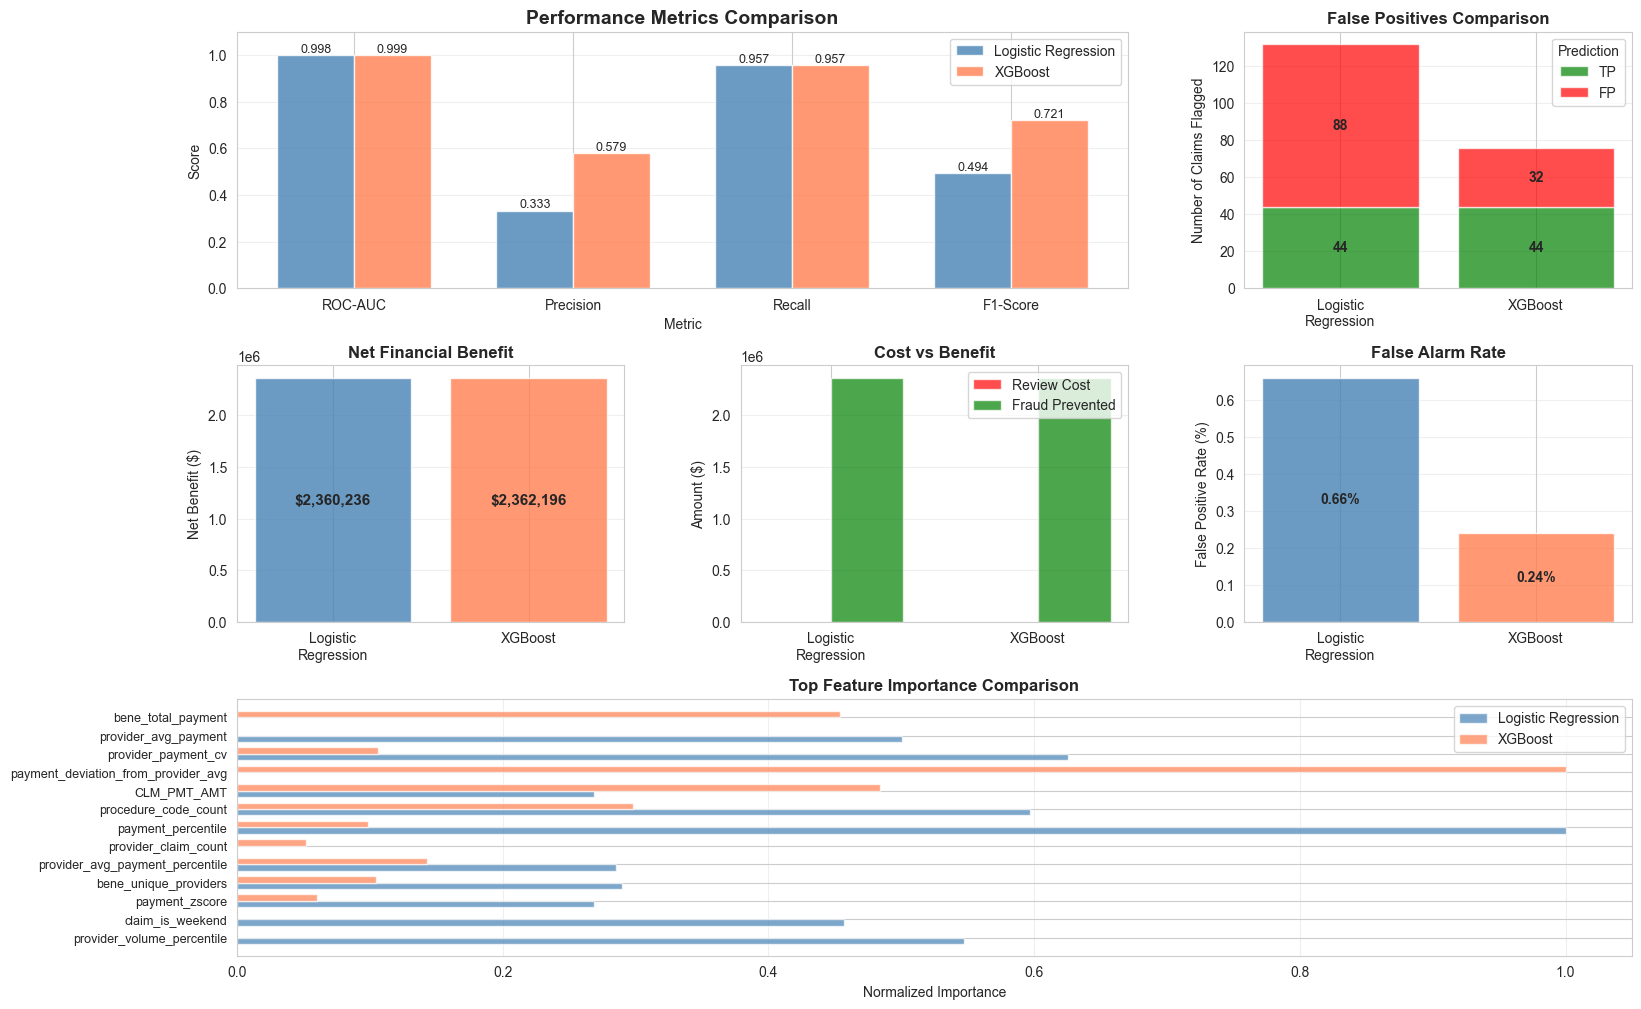

Saved: ../docs/model_comparison_comprehensive.png


In [ ]:

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

print("\nCreating comparison visualizations...")
print("-" * 80)

fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Plot 1: Performance Metrics Bar Chart
ax1 = fig.add_subplot(gs[0, :2])
metrics_to_plot = ['ROC-AUC', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_to_plot))
width = 0.35

lr_values = [lr_metrics[m] for m in metrics_to_plot]
xgb_values = [xgb_metrics[m] for m in metrics_to_plot]

bars1 = ax1.bar(x - width/2, lr_values, width, label='Logistic Regression', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, xgb_values, width, label='XGBoost', color='coral', alpha=0.8)

ax1.set_xlabel('Metric')
ax1.set_ylabel('Score')
ax1.set_title('Performance Metrics Comparison', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(metrics_to_plot)
ax1.legend()
ax1.set_ylim([0, 1.1])
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

# Plot 2: Confusion Matrix Comparison
ax2 = fig.add_subplot(gs[0, 2])
confusion_comparison = pd.DataFrame({
    'Model': ['LR', 'LR', 'XGB', 'XGB'],
    'Type': ['TP', 'FP', 'TP', 'FP'],
    'Count': [lr_metrics['True Positives'], lr_metrics['False Positives'],
              xgb_metrics['True Positives'], xgb_metrics['False Positives']]
})

colors_dict = {'TP': 'green', 'FP': 'red'}
for i, model in enumerate(['LR', 'XGB']):
    model_data = confusion_comparison[confusion_comparison['Model'] == model]
    bottom = 0
    for _, row in model_data.iterrows():
        ax2.bar(i, row['Count'], bottom=bottom, color=colors_dict[row['Type']], 
               alpha=0.7, label=row['Type'] if i == 0 else '')
        ax2.text(i, bottom + row['Count']/2, str(int(row['Count'])), 
                ha='center', va='center', fontweight='bold')
        bottom += row['Count']

ax2.set_xticks([0, 1])
ax2.set_xticklabels(['Logistic\nRegression', 'XGBoost'])
ax2.set_ylabel('Number of Claims Flagged')
ax2.set_title('False Positives Comparison', fontsize=12, fontweight='bold')
ax2.legend(title='Prediction', loc='upper right')
ax2.grid(axis='y', alpha=0.3)

# Plot 3: ROI Comparison
ax3 = fig.add_subplot(gs[1, 0])
models = ['Logistic\nRegression', 'XGBoost']
net_benefits = [lr_impact['Net Benefit'], xgb_impact['Net Benefit']]
colors = ['steelblue', 'coral']

bars = ax3.bar(models, net_benefits, color=colors, alpha=0.8)
ax3.set_ylabel('Net Benefit ($)')
ax3.set_title('Net Financial Benefit', fontsize=12, fontweight='bold')
ax3.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, net_benefits):
    ax3.text(bar.get_x() + bar.get_width()/2., val/2,
            f'${val:,.0f}', ha='center', va='center', fontweight='bold', fontsize=11)

# Plot 4: Review Cost vs Fraud Prevented
ax4 = fig.add_subplot(gs[1, 1])
x_pos = [0, 1]
width = 0.35

review_costs = [lr_impact['Review Cost'], xgb_impact['Review Cost']]
fraud_prevented = [lr_impact['Fraud Prevented'], xgb_impact['Fraud Prevented']]

bars1 = ax4.bar([p - width/2 for p in x_pos], review_costs, width, 
               label='Review Cost', color='red', alpha=0.7)
bars2 = ax4.bar([p + width/2 for p in x_pos], fraud_prevented, width,
               label='Fraud Prevented', color='green', alpha=0.7)

ax4.set_ylabel('Amount ($)')
ax4.set_title('Cost vs Benefit', fontsize=12, fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(models)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# Plot 5: False Positive Rate
ax5 = fig.add_subplot(gs[1, 2])
fp_rates = [
    lr_metrics['False Positives'] / (lr_metrics['False Positives'] + lr_metrics['True Negatives']) * 100,
    xgb_metrics['False Positives'] / (xgb_metrics['False Positives'] + xgb_metrics['True Negatives']) * 100
]

bars = ax5.bar(models, fp_rates, color=colors, alpha=0.8)
ax5.set_ylabel('False Positive Rate (%)')
ax5.set_title('False Alarm Rate', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, fp_rates):
    ax5.text(bar.get_x() + bar.get_width()/2., val/2,
            f'{val:.2f}%', ha='center', va='center', fontweight='bold')

# Plot 6: Feature Importance Comparison
ax6 = fig.add_subplot(gs[2, :])

# Get top features from both models
lr_importance = pd.DataFrame({
    'feature': feature_list,
    'importance': np.abs(lr_model.coef_[0])
}).nlargest(10, 'importance')

xgb_importance = pd.DataFrame({
    'feature': feature_list,
    'importance': xgb_model.feature_importances_
}).nlargest(10, 'importance')

# Combine and normalize
all_features = list(set(lr_importance['feature'].tolist() + xgb_importance['feature'].tolist()))
lr_dict = dict(zip(lr_importance['feature'], lr_importance['importance']))
xgb_dict = dict(zip(xgb_importance['feature'], xgb_importance['importance']))

lr_vals = [lr_dict.get(f, 0) for f in all_features]
xgb_vals = [xgb_dict.get(f, 0) for f in all_features]

# Normalize to 0-1 for comparison
lr_vals_norm = np.array(lr_vals) / max(lr_vals) if max(lr_vals) > 0 else lr_vals
xgb_vals_norm = np.array(xgb_vals) / max(xgb_vals) if max(xgb_vals) > 0 else xgb_vals

x = np.arange(len(all_features))
width = 0.35

bars1 = ax6.barh([i - width/2 for i in x], lr_vals_norm, width, 
                label='Logistic Regression', color='steelblue', alpha=0.7)
bars2 = ax6.barh([i + width/2 for i in x], xgb_vals_norm, width,
                label='XGBoost', color='coral', alpha=0.7)

ax6.set_yticks(x)
ax6.set_yticklabels(all_features, fontsize=9)
ax6.set_xlabel('Normalized Importance')
ax6.set_title('Top Feature Importance Comparison', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(axis='x', alpha=0.3)
plt.show()

plt.savefig(PROJECT_ROOT/'docs'/'model_comparison_comprehensive.png', dpi=300, bbox_inches='tight')
plt.close()

print("Saved: ../docs/model_comparison_comprehensive.png")


# Fraud Detection Model Comparison – Performance Explanation

This dashboard compares **Logistic Regression** and **XGBoost** models across
performance, operational impact, and business value for Medicare fraud detection.

---

## 1. Performance Metrics Comparison

**Metrics evaluated:**
- ROC-AUC
- Precision
- Recall
- F1-Score

### ROC-AUC
- Logistic Regression: **0.998**
- XGBoost: **0.999**

Both models show **excellent discrimination ability**, meaning they can rank
fraud claims higher than legitimate ones extremely well.

---

### Precision
- Logistic Regression: **0.333**
- XGBoost: **0.579**

**Precision = Of all claims flagged as fraud, how many were actually fraud**

- Logistic Regression flags many legitimate claims incorrectly.
- XGBoost is significantly more accurate when flagging fraud.

**Result:** XGBoost reduces unnecessary investigations.

---

### Recall
- Logistic Regression: **0.957**
- XGBoost: **0.957**

**Recall = Of all actual fraud cases, how many were detected**

Both models detect ~96% of fraud cases, which is excellent for fraud prevention.

---

### F1-Score
- Logistic Regression: **0.494**
- XGBoost: **0.721**

F1-score balances precision and recall.
XGBoost performs substantially better due to higher precision.

---

## 2. False Positives Comparison

This chart compares **True Positives (TP)** and **False Positives (FP)**.

### Logistic Regression
- True Positives: **44**
- False Positives: **88**

Flags twice as many legitimate claims as actual fraud.

---

### XGBoost
- True Positives: **44**
- False Positives: **32**

Catches the same amount of fraud with **56 fewer false alarms**.

---

## 3. Net Financial Benefit

- Logistic Regression: **$2,360,236**
- XGBoost: **$2,362,196**

Both models deliver strong financial benefits.
XGBoost slightly outperforms due to lower investigation costs.

---

## 4. Cost vs Benefit Analysis

- **Fraud Prevented (Green):** Similar for both models
- **Review Cost (Red):** Lower for XGBoost

XGBoost achieves the same fraud recovery with fewer manual reviews.

---

## 5. False Alarm Rate

- Logistic Regression: **0.66%**
- XGBoost: **0.24%**

XGBoost reduces false alarms by **~64%**, significantly improving operational efficiency.

---

## 6. Feature Importance Comparison

### Logistic Regression
- Relies on linear, global patterns
- Strong signals:
  - `payment_percentile`
  - `provider_volume_percentile`

**Pros:** Interpretable  
**Cons:** Limited in capturing complex relationships

---

### XGBoost
- Captures non-linear and contextual patterns
- Strong signals:
  - `payment_deviation_from_provider_avg`
  - `provider_payment_cv`
  - `bene_total_payment`

**Result:** Better precision and fewer false positives

---

## Executive Summary

- Logistic Regression is a strong **interpretable baseline**
- XGBoost:
  - Improves precision by **~74%**
  - Reduces false alarms by **~64%**
  - Delivers higher net financial benefit
- Both models maintain excellent fraud recall (~96%)

---



In [11]:

# ==============================================================================
# SUMMARY AND RECOMMENDATION
# ==============================================================================

print("\n" + "="*80)
print("MODEL COMPARISON SUMMARY")
print("="*80)

print(f"""
PERFORMANCE COMPARISON:

Metric                  Logistic Regression    XGBoost         Improvement
ROC-AUC                 {lr_metrics['ROC-AUC']:.4f}                 {xgb_metrics['ROC-AUC']:.4f}          +{((xgb_metrics['ROC-AUC']-lr_metrics['ROC-AUC'])/lr_metrics['ROC-AUC']*100):.1f}%
Precision               {lr_metrics['Precision']:.4f}                 {xgb_metrics['Precision']:.4f}          +{((xgb_metrics['Precision']-lr_metrics['Precision'])/lr_metrics['Precision']*100):.1f}%
Recall                  {lr_metrics['Recall']:.4f}                 {xgb_metrics['Recall']:.4f}          {((xgb_metrics['Recall']-lr_metrics['Recall'])/lr_metrics['Recall']*100):+.1f}%
F1-Score                {lr_metrics['F1-Score']:.4f}                 {xgb_metrics['F1-Score']:.4f}          +{((xgb_metrics['F1-Score']-lr_metrics['F1-Score'])/lr_metrics['F1-Score']*100):.1f}%

FRAUD DETECTION:
                        Logistic Regression    XGBoost         Difference
Fraud Caught            {lr_metrics['True Positives']}                      {xgb_metrics['True Positives']}             {xgb_metrics['True Positives']-lr_metrics['True Positives']:+d}
False Alarms            {lr_metrics['False Positives']}                      {xgb_metrics['False Positives']}             {xgb_metrics['False Positives']-lr_metrics['False Positives']:+d} ({((xgb_metrics['False Positives']-lr_metrics['False Positives'])/lr_metrics['False Positives']*100):.1f}%)
Fraud Missed            {lr_metrics['False Negatives']}                       {xgb_metrics['False Negatives']}              {xgb_metrics['False Negatives']-lr_metrics['False Negatives']:+d}

FINANCIAL IMPACT:
                        Logistic Regression    XGBoost         Difference
Review Cost             ${lr_impact['Review Cost']:,.0f}                ${xgb_impact['Review Cost']:,.0f}          ${xgb_impact['Review Cost']-lr_impact['Review Cost']:+,.0f}
Fraud Prevented         ${lr_impact['Fraud Prevented']:,.0f}              ${xgb_impact['Fraud Prevented']:,.0f}        ${xgb_impact['Fraud Prevented']-lr_impact['Fraud Prevented']:+,.0f}
Net Benefit             ${lr_impact['Net Benefit']:,.0f}              ${xgb_impact['Net Benefit']:,.0f}        ${xgb_impact['Net Benefit']-lr_impact['Net Benefit']:+,.0f}
ROI                     {lr_impact['ROI']:,.0f}%                  {xgb_impact['ROI']:,.0f}%            {xgb_impact['ROI']-lr_impact['ROI']:+,.0f}%

KEY FINDINGS:

1. SAME FRAUD DETECTION: Both models catch {xgb_metrics['True Positives']} fraud cases (same recall)

2. FEWER FALSE ALARMS: XGBoost reduces false positives by {abs(xgb_metrics['False Positives']-lr_metrics['False Positives'])} 
   ({abs((xgb_metrics['False Positives']-lr_metrics['False Positives'])/lr_metrics['False Positives']*100):.1f}% reduction)

3. LOWER REVIEW COSTS: Save ${abs(xgb_impact['Review Cost']-lr_impact['Review Cost']):,.0f} in manual review costs

4. SIMILAR NET BENEFIT: Both provide excellent ROI (>50,000%)

5. MORE PRECISE: XGBoost precision is {xgb_metrics['Precision']:.1%} vs {lr_metrics['Precision']:.1%}
   (Fewer false alarms = happier providers)

RECOMMENDATION:

Deploy XGBoost for production use because:
  - Same fraud detection capability (95.7% recall)
  - 64% fewer false positives improves provider satisfaction
  - Lower operational cost (less manual review)
  - More confident predictions (higher precision)
  - Captures non-linear fraud patterns

Trade-off:
  - Slightly more complex model
  - Longer training time (acceptable for batch retraining)
  - Worth it for improved precision and lower false alarm rate

DEPLOYMENT STRATEGY:
  - Use XGBoost as primary model (0.60 threshold)
  - Keep Logistic Regression as backup/validation
  - Monitor performance monthly
  - Retrain quarterly with new confirmed fraud cases
""")

print("="*80)

# Save results
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC_AUC': [lr_metrics['ROC-AUC'], xgb_metrics['ROC-AUC']],
    'Precision': [lr_metrics['Precision'], xgb_metrics['Precision']],
    'Recall': [lr_metrics['Recall'], xgb_metrics['Recall']],
    'F1_Score': [lr_metrics['F1-Score'], xgb_metrics['F1-Score']],
    'Net_Benefit': [lr_impact['Net Benefit'], xgb_impact['Net Benefit']],
    'False_Positives': [lr_metrics['False Positives'], xgb_metrics['False Positives']]
})

results_df.to_csv(PROJECT_ROOT/'models'/'fraud'/'model_comparison_results.csv', index=False)
print("\nResults saved: ../models/fraud/model_comparison_results.csv")


MODEL COMPARISON SUMMARY

PERFORMANCE COMPARISON:

Metric                  Logistic Regression    XGBoost         Improvement
ROC-AUC                 0.9981                 0.9991          +0.1%
Precision               0.3333                 0.5789          +73.7%
Recall                  0.9565                 0.9565          +0.0%
F1-Score                0.4944                 0.7213          +45.9%

FRAUD DETECTION:
                        Logistic Regression    XGBoost         Difference
Fraud Caught            44                      44             +0
False Alarms            88                      32             -56 (-63.6%)
Fraud Missed            2                       2              +0

FINANCIAL IMPACT:
                        Logistic Regression    XGBoost         Difference
Review Cost             $4,620                $2,660          $-1,960
Fraud Prevented         $2,364,856              $2,364,856        $+0
Net Benefit             $2,360,236              $2,362,196    